# Stacked ensemble: meta-LogReg over {Yu, v2, LogReg, SVM, XGBoost}

Base models score each example. A meta Logistic Regression learns how to combine those five scalars into a final `disp_E` probability.

**Splits used**
- Base models train on `tfrecords/train/*`.
- Meta learner trains on `tfrecords/val/*` (held out for all base models, so no leakage).
- Everything is evaluated on `tfrecords/test/*`.

**Prereqs** (run once before this notebook):
1. v2 ensemble trained into `checkpoints/fa1t_38_run_2`.
2. Yu ensemble trained into `runs/fa1t_yu` (in the Yu repo).
3. Yu predictions on **val** and **test** via `scripts/predict_yu_ensemble.py`:

```bash
cd /mnt/c/Users/danie/Documents/personal/test/astroyul/Astronet-Triage
PYTHONPATH=. python /mnt/c/Users/danie/Documents/personal/test/Astronet-Triage/scripts/predict_yu_ensemble.py \
    --model_root runs/fa1t_yu \
    --tfrecord_glob '/mnt/c/Users/danie/Documents/personal/test/Astronet-Triage/data/tfrecords/val/*' \
    --output_file /mnt/c/Users/danie/Documents/personal/test/Astronet-Triage/data/yu_ensemble_val.csv

PYTHONPATH=. python /mnt/c/Users/danie/Documents/personal/test/Astronet-Triage/scripts/predict_yu_ensemble.py \
    --model_root runs/fa1t_yu \
    --tfrecord_glob '/mnt/c/Users/danie/Documents/personal/test/Astronet-Triage/data/tfrecords/test/*' \
    --output_file /mnt/c/Users/danie/Documents/personal/test/Astronet-Triage/data/yu_ensemble_test.csv
```

In [2]:
import glob
import os

import numpy as np
import pandas as pd
import tensorflow as tf

TRAIN_GLOB = 'data/tfrecords/train/*'
VAL_GLOB = 'data/tfrecords/val/*'
TEST_GLOB = 'data/tfrecords/test/*'

V2_CHKPT_ROOT = 'checkpoints/fa1t_38_run_2'
YU_VAL_CSV = 'data/yu_ensemble_val.csv'
YU_TEST_CSV = 'data/yu_ensemble_test.csv'

NRUNS = 10
labels = ['disp_e', 'disp_n', 'disp_j', 'disp_s', 'disp_b']
col_e = labels.index('disp_e')

## 1. Load TFRecords — flat features + labels for train/val/test

In [3]:
def load_split(pattern):
    astro_ids, gv, lv, disp_e = [], [], [], []
    for f in sorted(glob.glob(pattern)):
        for rec in tf.data.TFRecordDataset(f):
            ex = tf.train.Example.FromString(rec.numpy())
            feat = ex.features.feature
            astro_ids.append(feat['astro_id'].int64_list.value[0])
            gv.append(list(feat['global_view'].float_list.value))
            lv.append(list(feat['local_view'].float_list.value))
            disp_e.append(feat['disp_E'].int64_list.value[0])
    gv_arr = np.asarray(gv, dtype=np.float32)
    lv_arr = np.asarray(lv, dtype=np.float32)
    X = np.concatenate([gv_arr, lv_arr], axis=1)
    y = (np.asarray(disp_e, dtype=np.int64) > 0).astype(int)
    return np.asarray(astro_ids), X, y


astro_train, X_train, y_train = load_split(TRAIN_GLOB)
astro_val,   X_val,   y_val   = load_split(VAL_GLOB)
astro_test,  X_test,  y_test  = load_split(TEST_GLOB)

print(f'train: {X_train.shape}  pos={y_train.mean():.3f}')
print(f'val  : {X_val.shape}  pos={y_val.mean():.3f}')
print(f'test : {X_test.shape}  pos={y_test.mean():.3f}')

train: (19918, 262)  pos=0.105
val  : (2491, 262)  pos=0.105
test : (2516, 262)  pos=0.099


## 2. Base classical models (LogReg, SVM, XGBoost)
Train on train; predict on val + test.

In [4]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
import xgboost as xgb

logreg = Pipeline([('scale', StandardScaler()),
                   ('clf', LogisticRegression(max_iter=2000, C=1.0, solver='lbfgs', n_jobs=-1))])
logreg.fit(X_train, y_train)
p_lr_val  = logreg.predict_proba(X_val)[:, 1]
p_lr_test = logreg.predict_proba(X_test)[:, 1]
print('LogReg done')

svm = Pipeline([('scale', StandardScaler()),
                ('clf', SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=0))])
svm.fit(X_train, y_train)
p_svm_val  = svm.predict_proba(X_val)[:, 1]
p_svm_test = svm.predict_proba(X_test)[:, 1]
print('SVM done')

xgbc = xgb.XGBClassifier(n_estimators=400, max_depth=6, learning_rate=0.1,
                         subsample=0.9, colsample_bytree=0.9,
                         eval_metric='logloss', n_jobs=-1, random_state=0)
xgbc.fit(X_train, y_train)
p_xgb_val  = xgbc.predict_proba(X_val)[:, 1]
p_xgb_test = xgbc.predict_proba(X_test)[:, 1]
print('XGBoost done')

c:\Users\danie\anaconda3\envs\astronet\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


LogReg done
SVM done
XGBoost done


## 3. v2 ensemble base scores (inline)
Average `disp_e` across the 10 v2 models on val and test.

In [5]:
from astronet import predict as v2_predict


def load_v2_ensemble(root, nruns):
    paths = []
    for i in range(nruns):
        parent = os.path.join(root, str(i + 1))
        if not os.path.exists(parent):
            break
        subs = os.listdir(parent)
        if not subs:
            break
        d, = subs
        paths.append(os.path.join(parent, d))
    return paths


v2_paths = load_v2_ensemble(V2_CHKPT_ROOT, NRUNS)
print(f'{len(v2_paths)} v2 checkpoints')


def v2_mean_scores(paths, data_files, astro_ids):
    idx = {v: i for i, v in enumerate(astro_ids)}
    mat = np.zeros([len(paths), len(astro_ids)])
    for k, path in enumerate(paths):
        v2_predict.FLAGS = v2_predict.parser.parse_args([
            '--model_dir', path,
            '--data_files', data_files,
            '--output_file', '',
        ])
        preds, _ = v2_predict.predict()
        for ex_id, row in preds.set_index('astro_id').iterrows():
            if ex_id in idx:
                mat[k][idx[ex_id]] = row.iloc[col_e]
        print(f'  v2 model {k + 1}/{len(paths)} done')
    return mat.mean(axis=0)


print('v2 on val...')
v2_val  = v2_mean_scores(v2_paths, VAL_GLOB,  astro_val)
print('v2 on test...')
v2_test = v2_mean_scores(v2_paths, TEST_GLOB, astro_test)

10 v2 checkpoints
v2 on val...
2491 records  v2 model 1/10 done
2491 records  v2 model 2/10 done
2491 records  v2 model 3/10 done
2491 records  v2 model 4/10 done
2491 records  v2 model 5/10 done
2491 records  v2 model 6/10 done
2491 records  v2 model 7/10 done
2491 records  v2 model 8/10 done
2491 records  v2 model 9/10 done
2491 records  v2 model 10/10 done
v2 on test...
2516 records  v2 model 1/10 done
2516 records  v2 model 2/10 done
2516 records  v2 model 3/10 done
2516 records  v2 model 4/10 done
2516 records  v2 model 5/10 done
2516 records  v2 model 6/10 done
2516 records  v2 model 7/10 done
2516 records  v2 model 8/10 done
2516 records  v2 model 9/10 done
2516 records  v2 model 10/10 done


## 4. Yu ensemble base scores (from pre-computed CSVs)

In [6]:
def yu_mean_from_csv(csv_path, astro_ids):
    df = pd.read_csv(csv_path).set_index('astro_id')
    cols = [c for c in df.columns if c.startswith('yu_pred_')]
    scores = df[cols].mean(axis=1)
    out = np.full(len(astro_ids), np.nan, dtype=np.float64)
    for i, a in enumerate(astro_ids):
        if a in scores.index:
            out[i] = scores.loc[a]
    missing = int(np.isnan(out).sum())
    print(f'  {csv_path}: {len(astro_ids) - missing}/{len(astro_ids)} matched')
    return out


yu_val  = yu_mean_from_csv(YU_VAL_CSV,  astro_val)
yu_test = yu_mean_from_csv(YU_TEST_CSV, astro_test)

  data/yu_ensemble_val.csv: 2491/2491 matched
  data/yu_ensemble_test.csv: 2516/2516 matched


## 5. Meta Logistic Regression
Features: `[yu, v2, logreg, svm, xgb]`. Fit on val scores → val labels.

In [7]:
FEATURE_NAMES = ['yu', 'v2', 'logreg', 'svm', 'xgb']

meta_X_val  = np.column_stack([yu_val,  v2_val,  p_lr_val,  p_svm_val,  p_xgb_val])
meta_X_test = np.column_stack([yu_test, v2_test, p_lr_test, p_svm_test, p_xgb_test])

mask_val  = np.all(np.isfinite(meta_X_val),  axis=1)
mask_test = np.all(np.isfinite(meta_X_test), axis=1)
print(f'val : {mask_val.sum()}/{len(mask_val)} usable')
print(f'test: {mask_test.sum()}/{len(mask_test)} usable')

meta = LogisticRegression(max_iter=2000, C=1.0)
meta.fit(meta_X_val[mask_val], y_val[mask_val])
p_meta = meta.predict_proba(meta_X_test[mask_test])[:, 1]
y_test_eff = y_test[mask_test]

coef_df = pd.DataFrame({
    'feature': FEATURE_NAMES + ['(intercept)'],
    'coef': list(meta.coef_[0]) + [meta.intercept_[0]],
})
coef_df

val : 2491/2491 usable
test: 2516/2516 usable


,feature,coef
0,yu,1.730258
1,v2,5.725491
2,logreg,1.415246
3,svm,0.196535
4,xgb,0.634224
5,(intercept),-4.944922


## 6. PR curves — each base vs meta (on test)

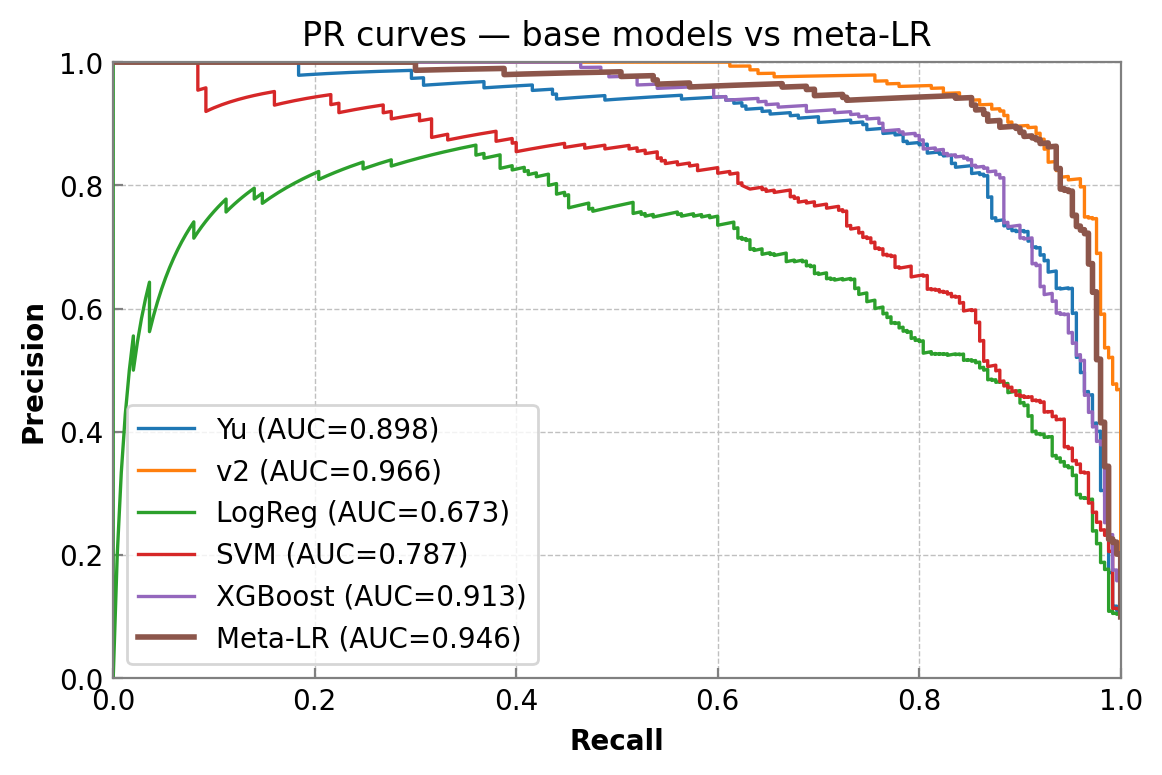

,PR_AUC
model,
Yu,0.898333
v2,0.965749
LogReg,0.673494
SVM,0.786709
XGBoost,0.913303
Meta-LR,0.945722


In [8]:
from sklearn import metrics
from matplotlib import pyplot as plt

base_scores = {
    'Yu':      yu_test[mask_test],
    'v2':      v2_test[mask_test],
    'LogReg':  p_lr_test[mask_test],
    'SVM':     p_svm_test[mask_test],
    'XGBoost': p_xgb_test[mask_test],
    'Meta-LR': p_meta,
}

fig, ax = plt.subplots(figsize=(6.5, 4), dpi=200)
for side in ('top', 'right', 'left', 'bottom'):
    ax.spines[side].set_color('#808080')
ax.tick_params(direction='in', color='#808080')
ax.grid(color='#c0c0c0', linestyle='--', linewidth=0.5)

pr_rows = []
for name, p in base_scores.items():
    ps, rs, _ = metrics.precision_recall_curve(y_test_eff, p)
    auc = metrics.auc(rs, ps)
    lw = 2.0 if name == 'Meta-LR' else 1.2
    ax.plot(rs, ps, label=f'{name} (AUC={auc:.3f})', linewidth=lw)
    pr_rows.append({'model': name, 'PR_AUC': auc})

ax.set_xlabel('Recall', fontweight='bold'); ax.set_ylabel('Precision', fontweight='bold')
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.legend(loc='lower left')
ax.set_title('PR curves — base models vs meta-LR')
plt.show()

pd.DataFrame(pr_rows).set_index('model')

## 7. Confusion matrices at p ≥ 0.5

=== Yu  th=0.5 ===  TP=206 FP=36 FN=44 TN=2230  P=0.8512 R=0.8240


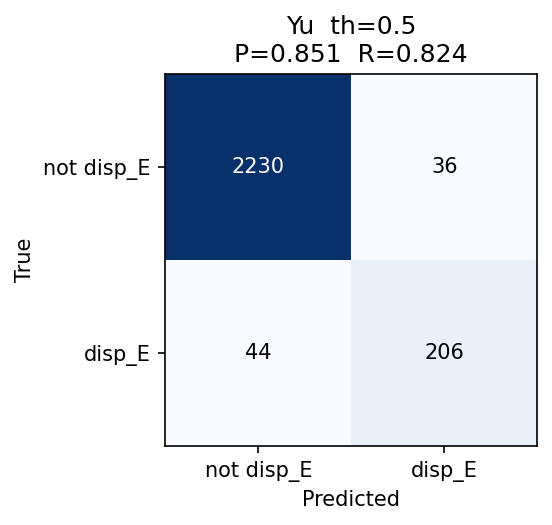

=== v2  th=0.5 ===  TP=230 FP=33 FN=20 TN=2233  P=0.8745 R=0.9200


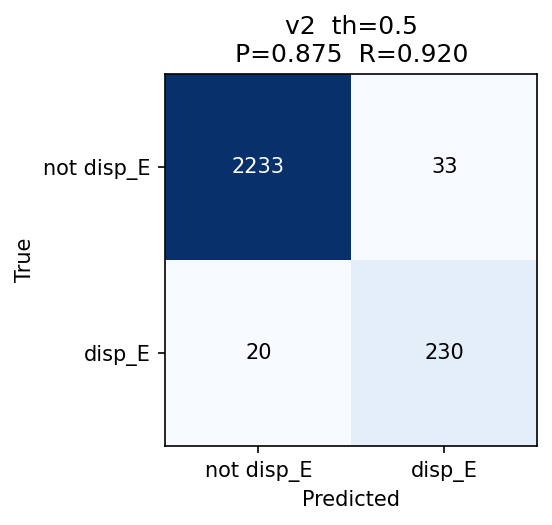

=== LogReg  th=0.5 ===  TP=134 FP=45 FN=116 TN=2221  P=0.7486 R=0.5360


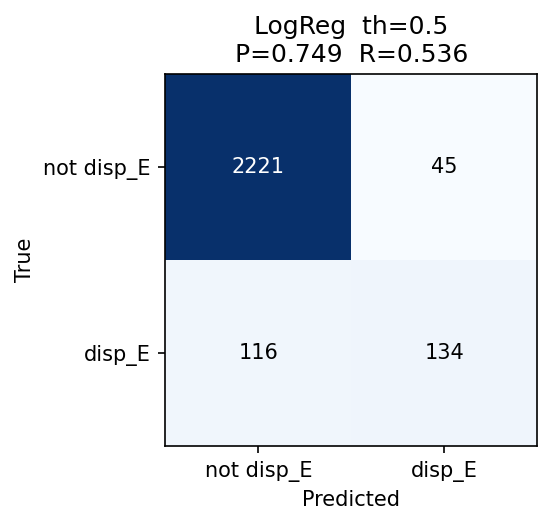

=== SVM  th=0.5 ===  TP=158 FP=41 FN=92 TN=2225  P=0.7940 R=0.6320


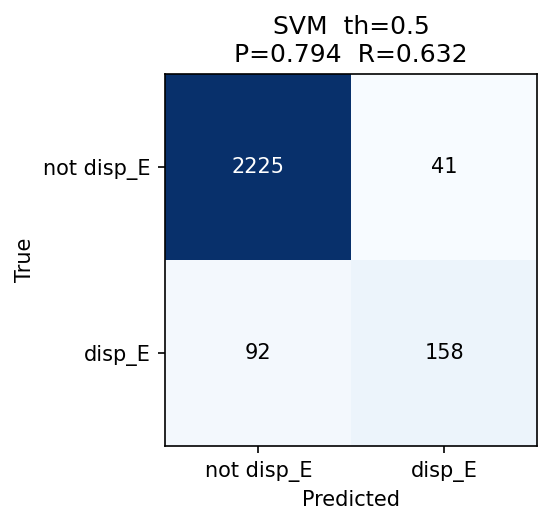

=== XGBoost  th=0.5 ===  TP=201 FP=32 FN=49 TN=2234  P=0.8627 R=0.8040


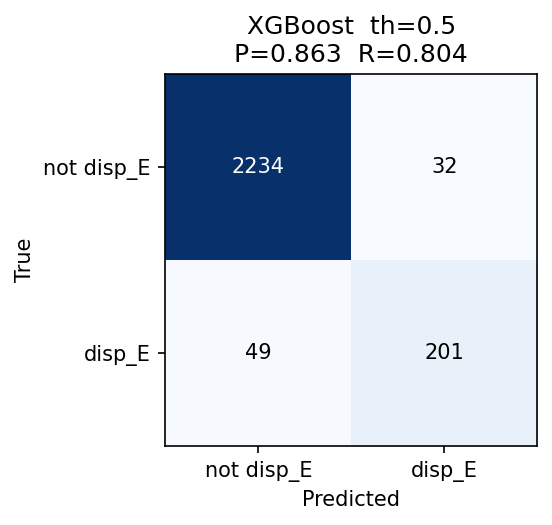

=== Meta-LR  th=0.5 ===  TP=225 FP=28 FN=25 TN=2238  P=0.8893 R=0.9000


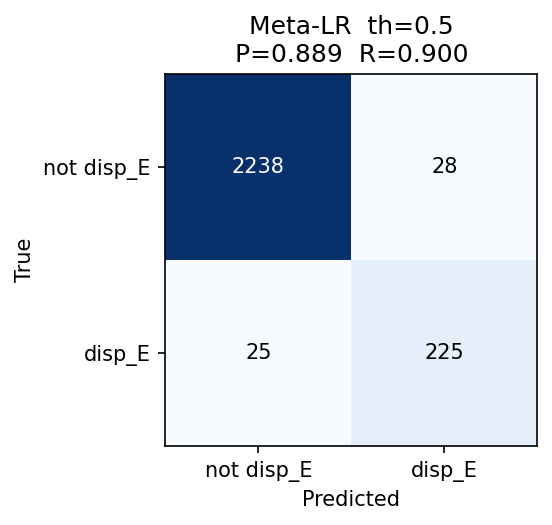

In [9]:
from sklearn.metrics import confusion_matrix

bin_labels = ['not disp_E', 'disp_E']


def show_cm(name, p, th=0.5):
    y_pred_bin = (p >= th).astype(int)
    cm = confusion_matrix(y_test_eff, y_pred_bin, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    prec = tp / (tp + fp) if (tp + fp) else 0.0
    rec = tp / (tp + fn) if (tp + fn) else 0.0
    print(f'=== {name}  th={th} ===  TP={tp} FP={fp} FN={fn} TN={tn}  P={prec:.4f} R={rec:.4f}')

    fig, ax = plt.subplots(figsize=(4.2, 3.6), dpi=150)
    im = ax.imshow(cm, cmap='Blues')
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(bin_labels); ax.set_yticklabels(bin_labels)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title(f'{name}  th={th}\nP={prec:.3f}  R={rec:.3f}')
    mid = cm.max() / 2.0
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                    color='white' if cm[i, j] > mid else 'black')
    plt.tight_layout(); plt.show()


for name, p in base_scores.items():
    show_cm(name, p)

## 8. Summary table
PR-AUC, P/R at 0.5, and P at 100%-recall for each base and the meta.

In [10]:
def full_recall_precision(y_true, p):
    ps, rs, ths = metrics.precision_recall_curve(y_true, p)
    idx = np.where(rs == 1.0)[0]
    if len(idx) == 0:
        return 0.0, None
    i = int(idx.max())
    th = float(ths[i - 1]) if i > 0 and i - 1 < len(ths) else None
    return float(ps[i]), th


rows = []
for name, p in base_scores.items():
    ps, rs, _ = metrics.precision_recall_curve(y_test_eff, p)
    auc = metrics.auc(rs, ps)
    y_pred = (p >= 0.5).astype(int)
    cm = confusion_matrix(y_test_eff, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    prec = tp / (tp + fp) if (tp + fp) else 0.0
    rec = tp / (tp + fn) if (tp + fn) else 0.0
    p100, th100 = full_recall_precision(y_test_eff, p)
    rows.append({
        'model': name,
        'PR_AUC': auc,
        'P@0.5': prec, 'R@0.5': rec,
        'TP': tp, 'FP': fp, 'FN': fn, 'TN': tn,
        'P@100R': p100, 'threshold@100R': th100,
    })

pd.DataFrame(rows).set_index('model')

,PR_AUC,P@0.5,R@0.5,TP,FP,FN,TN,P@100R,threshold@100R
model,,,,,,,,,
Yu,0.898333,0.851240,0.824,206,36,44,2230,0.110181,0.000020
v2,0.965749,0.874525,0.920,230,33,20,2233,0.469043,0.008053
LogReg,0.673494,0.748603,0.536,134,45,116,2221,0.104123,0.000002
SVM,0.786709,0.793970,0.632,158,41,92,2225,0.113071,0.000002
XGBoost,0.913303,0.862661,0.804,201,32,49,2234,0.158629,0.000014
Meta-LR,0.945722,0.889328,0.900,225,28,25,2238,0.201939,0.007476
